In [129]:
import numpy as np

from TimeSeriesGeneratorV2 import EventTimestampGenerator, EventSampleSpace, TimeSeriesGenerator

In [130]:
N = 3
time_intervals = [(i, i+1) for i in range(N)]
occurrences = [i+1 for i in range(N)]
noise_sds = [.5]*N
no_occurrences_sds = [0]*N

print("Time intervals:", time_intervals)
print("Occurrences:", occurrences)
print("Period standard deviations:", noise_sds)
print("Number of occurrences standard deviations:", no_occurrences_sds)

Time intervals: [(0, 1), (1, 2), (2, 3)]
Occurrences: [1, 2, 3]
Period standard deviations: [0.5, 0.5, 0.5]
Number of occurrences standard deviations: [0, 0, 0]


In [131]:
class ExampleETG(EventTimestampGenerator):
    """Class representing the frequency of events over time, defined by occurrences and time intervals"""
    def __init__(self, occurrences, time_intervals, noise_sds):
        super().__init__(occurrences, time_intervals)
        self.noise_sds = noise_sds
        
    def sample_noise (self, i):
        """Samples a timing interval"""
        return np.random.normal(loc=0, scale=self.noise_sds[i])


class ExampleSampleSpace(EventSampleSpace):
    def __init__(self):
        super().__init__()
    
    def sample(self, t):
        return np.random.normal(loc=1, scale=0)

In [132]:
etg = ExampleETG(occurrences, time_intervals, noise_sds)
ess = ExampleSampleSpace()

In [133]:
def on_event(event):
    print(f"event: {event}")
    print("--------")

time_series_generator = TimeSeriesGenerator([(etg, ess)], on_event)
data = time_series_generator.run(N*2)
print("Generated data:", data)

event: (0.7754164476434815, 1.0)
--------
event: (2.3314407779069763, 1.0)
--------
event: (2.6747143566815033, 1.0)
--------
event: (1.2563792234195938, 1.0)
--------
event: (1.7746544476314758, 1.0)
--------
event: (2.090348684741124, 1.0)
--------
event: (3.734357244318426, 1.0)
--------
event: (4.061488722454965, 1.0)
--------
event: (4.785693564757498, 1.0)
--------
event: (5.265757835856382, 1.0)
--------
event: (5.741150995849897, 1.0)
--------
Generated data: [(0.7754164476434815, 1.0), (2.3314407779069763, 1.0), (2.6747143566815033, 1.0), (1.2563792234195938, 1.0), (1.7746544476314758, 1.0), (2.090348684741124, 1.0), (3.734357244318426, 1.0), (4.061488722454965, 1.0), (4.785693564757498, 1.0), (5.265757835856382, 1.0), (5.741150995849897, 1.0)]


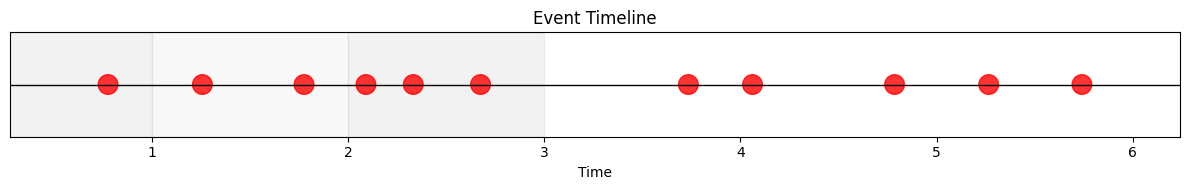

In [134]:
import matplotlib.pyplot as plt

# Assume `data` is a list of (time, scale) tuples,
# and `time_intervals` is a list of (start, end) tuples, already defined.

# Unpack times and scales
times, scales = zip(*data)

# All events sit on the same horizontal line
ys = [0] * len(times)

# Map scales to marker sizes (adjust the multiplier as needed)
marker_sizes = [s * 200 for s in scales]

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 2))

# Draw baseline timeline
ax.hlines(0, min(times) - 0.5, max(times) + 0.5, color='black', linewidth=1)

# Shade each period for context
for idx, (start, end) in enumerate(time_intervals):
    alpha = 0.1 if idx % 2 == 0 else 0.05
    ax.axvspan(start, end, color='gray', alpha=alpha)

# Plot events as red circles
ax.scatter(times, ys, s=marker_sizes, color='red', alpha=0.8)

# Hide y-axis ticks and labels
ax.set_yticks([])

# Labels and title
ax.set_xlabel('Time')
ax.set_title('Event Timeline')

# Set plot limits
ax.set_xlim(min(times) - 0.5, max(times) + 0.5)
ax.set_ylim(-0.5, 0.5)

plt.tight_layout()
plt.show()


In [135]:
# import matplotlib.pyplot as plt


# def plot_multiple_timelines(data_list, time_intervals, titles, colors):
#     """
#     Plot multiple event timelines stacked vertically.

#     Parameters:
#     - data_list: List of data sources, each being a list of (time, scale) tuples.
#     - time_intervals: List of (start, end) tuples defining shaded periods.
#     - titles: List of titles for each subplot.
#     - colors: List of colors for the markers of each subplot.

#     Each timeline will be drawn on its own subplot, sharing the same x-axis.
#     """
#     n = len(data_list)
#     if not (len(titles) == len(colors) == n):
#         raise ValueError("data_list, titles and colors must have the same length")

#     # Create subplots, one row per data source
#     fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(12, 2 * n), sharex=True)
#     if n == 1:
#         axes = [axes]

#     # Determine global x-limits from all data
#     all_times = [t for data in data_list for t, _ in data]
#     xmin, xmax = min(all_times) - 0.5, max(all_times) + 0.5

#     for i, (data, title, color) in enumerate(zip(data_list, titles, colors)):
#         times, scales = zip(*data)
#         ys = [0] * len(times)
#         marker_sizes = [s * 200 for s in scales]

#         ax = axes[i]
#         # Draw baseline timeline
#         ax.hlines(0, xmin, xmax, color='black', linewidth=1)

#         # Shade each period for context
#         for idx, (start, end) in enumerate(time_intervals):
#             alpha = 0.1 if idx % 2 == 0 else 0.05
#             ax.axvspan(start, end, color='gray', alpha=alpha)

#         # Plot events
#         ax.scatter(times, ys, s=marker_sizes, color=color, alpha=0.8)

#         # Hide y-axis
#         ax.set_yticks([])
#         ax.set_ylabel(title, rotation=0, labelpad=40, va='center')

#         # Only label x-axis on the bottom plot
#         if i == n - 1:
#             ax.set_xlabel('Time')

#         # Set vertical limits to center the line
#         ax.set_xlim(xmin, xmax)
#         ax.set_ylim(-0.5, 0.5)

#     plt.tight_layout()
#     plt.show()

# data_list = [data, data_ideal, data_shifted, data_ideal_shifted]
# titles = ['Data', 'Ideal Data', 'Shifted Data', 'Ideal \n Shifted Data']
# colors = ['red', 'blue', 'green', 'orange']
# plot_multiple_timelines(data_list, time_intervals, titles, colors)

In [136]:
from Analytics import count_number_of_occurrences_in_intervals
print(data)
count_number_of_occurrences_in_intervals(time_intervals, data)

[(0.7754164476434815, 1.0), (2.3314407779069763, 1.0), (2.6747143566815033, 1.0), (1.2563792234195938, 1.0), (1.7746544476314758, 1.0), (2.090348684741124, 1.0), (3.734357244318426, 1.0), (4.061488722454965, 1.0), (4.785693564757498, 1.0), (5.265757835856382, 1.0), (5.741150995849897, 1.0)]


[1, 2, 3]